# Neo4j Graph Database for Microbiome Knowledge Network Construction and Cypher-Based Analysis

First, install the Neo4j and NetworkX libraries required for graph database access and network analysis.

In [1]:
!pip install neo4j networkx


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Then, import the libraries needed to connect to Neo4j and build graph visualizations.

In [3]:
# Import libraries
from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

This connects the notebook to the local Neo4j database using the provided credentials.

In [ ]:
# Connect to Neo4j
URI = "bolt://localhost:7687"
USERNAME = "neo4j"
PASSWORD = "####"

driver = GraphDatabase.driver(
    URI,
    auth=(USERNAME, PASSWORD)
)

print("Connected to Neo4j!")

Connected to Neo4j!


This defines a helper function that runs Cypher queries and returns the results as a pandas DataFrame.

In [ ]:
# Helper function
def run_query(query):

    with driver.session() as session:

        result = session.run(query)

        return pd.DataFrame(result.data())

Count all nodes in the knowledge graph to understand its overall size using Cypher.

In [ ]:
#Count nodes
query = """
MATCH (n)
RETURN count(n) AS Total_Nodes
"""

run_query(query)

,Total_Nodes
0,26


Count all relationships in the graph to summarize how connected the data is.

In [7]:
# Count relationships
query = """
MATCH ()-[r]->()
RETURN count(r) AS Total_Relationships
"""

run_query(query)

,Total_Relationships
0,40


This groups nodes by label to show the distribution of entity types in the graph.

In [ ]:
# Number of nodes by label
query = """
MATCH (n)
RETURN labels(n)[0] AS Label,
count(*) AS Count
"""

run_query(query)

,Label,Count
0,Microbe,6
1,Disease,5
2,Metabolite,5
3,Pathway,5
4,Gene,5


It lists all disease entities stored in the knowledge graph.

In [8]:
# Diseases
query = """
MATCH (d:Disease)

RETURN d.name AS Disease
"""

run_query(query)

,Disease
0,Colorectal Cancer
1,Inflammatory Bowel Disease
2,Type 2 Diabetes
3,Obesity
4,Cardiovascular Disease


list all microbes stored in the graph as a simple reference dataset.

In [9]:
# Microbes
query = """
MATCH (m:Microbe)

RETURN m.name AS Microbe
"""

run_query(query)

,Microbe
0,Akkermansia muciniphila
1,Faecalibacterium prausnitzii
2,Bacteroides fragilis
3,Escherichia coli
4,Lactobacillus rhamnosus
5,Fusobacterium nucleatum


Now, retrieve the associations between microbes and diseases from the graph.

In [12]:
# Microbe-Disease associations
query = """
MATCH (m:Microbe)-[:ASSOCIATED]->(d:Disease)

RETURN
m.name AS Microbe,
d.name AS Disease
"""

df = run_query(query)

df

,Microbe,Disease
0,Akkermansia muciniphila,Type 2 Diabetes
1,Faecalibacterium prausnitzii,Inflammatory Bowel Disease
2,Bacteroides fragilis,Colorectal Cancer
3,Escherichia coli,Inflammatory Bowel Disease
4,Escherichia coli,Cardiovascular Disease
5,Lactobacillus rhamnosus,Obesity
6,Fusobacterium nucleatum,Colorectal Cancer


Now, view the relationship between microbes and metabolites produced by them.

In [ ]:
# Microbe → Metabolite
query = """
MATCH (m:Microbe)-[:PRODUCES]->(met:Metabolite)

RETURN
m.name AS Microbe,
met.name AS Metabolite
"""

run_query(query)

,Microbe,Metabolite
0,Akkermansia muciniphila,Propionate
1,Faecalibacterium prausnitzii,Butyrate
2,Bacteroides fragilis,Acetate
3,Bacteroides fragilis,Secondary Bile Acid
4,Escherichia coli,Lipopolysaccharide
5,Lactobacillus rhamnosus,Butyrate
6,Fusobacterium nucleatum,Lipopolysaccharide


Extract the disease-pathway connections to trace biological processes.

In [14]:
# Disease pathways
query = """
MATCH (d:Disease)-[:INVOLVES]->(p:Pathway)

RETURN
d.name AS Disease,
p.name AS Pathway
"""

run_query(query)

,Disease,Pathway
0,Colorectal Cancer,None
1,Colorectal Cancer,None
2,Inflammatory Bowel Disease,None
3,Type 2 Diabetes,None
4,Obesity,None
5,Cardiovascular Disease,None


This show the complete biological chain linking microbes, metabolites, pathways, and diseases.

In [17]:
# Complete biological chain
query = """
MATCH

(m:Microbe)-[:PRODUCES]->
(met:Metabolite)-[:AFFECTS]->
(p:Pathway)<-[:INVOLVES]-
(d:Disease)

RETURN

m.name AS Microbe,
met.name AS Metabolite,
p.name AS Pathway,
d.name AS Disease
"""

run_query(query)

,Microbe,Metabolite,Pathway,Disease
0,Faecalibacterium prausnitzii,Butyrate,None,Inflammatory Bowel Disease
1,Lactobacillus rhamnosus,Butyrate,None,Inflammatory Bowel Disease
2,Bacteroides fragilis,Acetate,None,Type 2 Diabetes
3,Bacteroides fragilis,Acetate,None,Obesity
4,Escherichia coli,Lipopolysaccharide,None,Colorectal Cancer
5,Fusobacterium nucleatum,Lipopolysaccharide,None,Colorectal Cancer
6,Escherichia coli,Lipopolysaccharide,None,Cardiovascular Disease
7,Fusobacterium nucleatum,Lipopolysaccharide,None,Cardiovascular Disease
8,Bacteroides fragilis,Secondary Bile Acid,None,Colorectal Cancer


Filter the graph to focus on microbes associated with colorectal cancer.

In [19]:
# Microbes linked to Colorectal Cancer
query = """
MATCH

(m:Microbe)-[:ASSOCIATED]->(d:Disease)

WHERE d.name="Colorectal Cancer"

RETURN

m.name AS Microbe
"""

run_query(query)

,Microbe
0,Bacteroides fragilis
1,Fusobacterium nucleatum


Create a bar chart showing how many microbes are linked to each disease.

In [ ]:
# Bar chart
query = """
MATCH

(m:Microbe)-[:ASSOCIATED]->(d:Disease)

RETURN

d.name AS Disease,
count(m) AS Microbes
"""

df = run_query(query)

df

,Disease,Microbes
0,Type 2 Diabetes,1
1,Inflammatory Bowel Disease,2
2,Colorectal Cancer,2
3,Cardiovascular Disease,1
4,Obesity,1


It prepares the data for visualization by counting microbes per disease. Then draw the bar chart that visualizes the number of microbes associated with each disease.

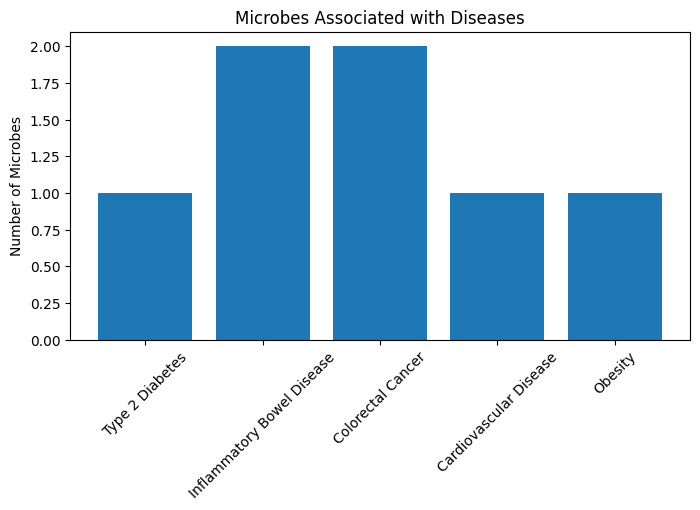

In [23]:
plt.figure(figsize=(8,4))
plt.bar(df["Disease"], df["Microbes"])
plt.xticks(rotation=45)
plt.ylabel("Number of Microbes")
plt.title("Microbes Associated with Diseases")
plt.show()

It builds the edge list needed to represent the microbe-disease network in NetworkX.

In [24]:
# Create NetworkX graph
query = """
MATCH

(m:Microbe)-[:ASSOCIATED]->(d:Disease)

RETURN

m.name AS source,
d.name AS target
"""

df = run_query(query)

df.head()

,source,target
0,Akkermansia muciniphila,Type 2 Diabetes
1,Faecalibacterium prausnitzii,Inflammatory Bowel Disease
2,Bacteroides fragilis,Colorectal Cancer
3,Escherichia coli,Inflammatory Bowel Disease
4,Escherichia coli,Cardiovascular Disease


It visualizes the microbe-disease graph as a labeled network diagram.

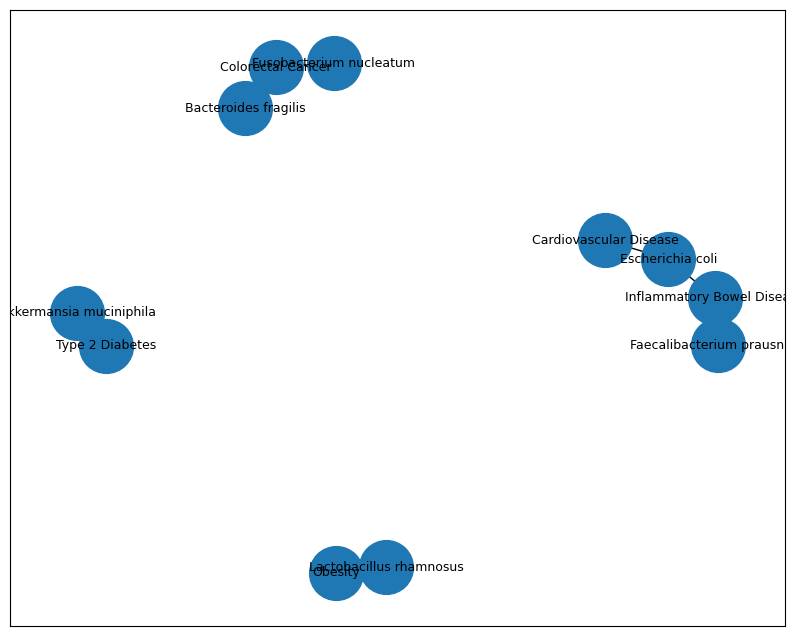

In [25]:
# Visualize network
G = nx.from_pandas_edgelist(
    df,
    source="source",
    target="target"
)

plt.figure(figsize=(10,8))

nx.draw_networkx(
    G,
    with_labels=True,
    node_size=1500,
    font_size=9
)

plt.show()

In [ ]:
# Close connection
driver.close()

This cell closes the Neo4j connection once the analysis is complete.